# Level 4: Basic Analysis and Visualization

In [129]:
import pandas as pd
import matplotlib.pyplot as plt

In [130]:
data=pd.read_csv("C:/Users/lavanya/Downloads/Internship_Files/Raw_Dataset.csv")
df=pd.DataFrame(data)
print(df)

        SN  Train_No Station_Code    1A    2A    3A    SL     Station_Name  \
0        1       107          SWV   100   100   100   100     SAWANTWADI R   
1        2       107         THVM   260   228   196   164           THIVIM   
2        3       107         KRMI   345   296   247   198          KARMALI   
3        4       107          MAO   490   412   334   256      MADGOAN JN.   
4        1       108          MAO   100   100   100   100      MADGOAN JN.   
...     ..       ...          ...   ...   ...   ...   ...              ...   
186069   1     22439         NDLS   100   100   100   100        NEW DELHI   
186070   2     22439          UMB  1095   896   697  1095   AMBALA CANT JN   
186071   3     22439          LDH  1660  1348  1036  1660      LUDHIANA JN   
186072   4     22439          JAT  2985  2408  1831  2985       JAMMU TAWI   
186073   5     22439         SVDK  3375  2720  2065  3375  SHMATA VD KATRA   

        Route_Number Arrival_time Departure_Time  Distance  
0 

TASK_2

In [138]:
df[["Train_No","Arrival_time","Departure_Time"]].head(40)

,Train_No,Arrival_time,Departure_Time
0,107,00:00:00,10:25:00
1,107,11:06:00,11:08:00
2,107,11:28:00,11:30:00
3,107,12:10:00,00:00:00
4,108,00:00:00,20:30:00
5,108,21:04:00,21:06:00
6,108,21:26:00,21:28:00
7,108,22:25:00,00:00:00
8,128,19:40:00,19:40:00
9,128,20:18:00,20:20:00


In [139]:
df["Arrival_time"] = pd.to_timedelta(df["Arrival_time"])
df["Departure_Time"] = pd.to_timedelta(df["Departure_Time"] )

In [140]:
df[["Train_No","Arrival_time","Departure_Time"]].head()

,Train_No,Arrival_time,Departure_Time
0,107,0 days 00:00:00,0 days 10:25:00
1,107,0 days 11:06:00,0 days 11:08:00
2,107,0 days 11:28:00,0 days 11:30:00
3,107,0 days 12:10:00,0 days 00:00:00
4,108,0 days 00:00:00,0 days 20:30:00


In [141]:
Train_Journey = df.groupby("Train_No").agg(Starting_Time=("Departure_Time", "first"),Ending_Time=("Arrival_time", "last")).reset_index()

In [142]:
Train_Journey.loc[Train_Journey["Ending_Time"] < Train_Journey["Starting_Time"], "Ending_Time"]+= pd.Timedelta("1 day")

In [143]:
Train_Journey["Journey_Duration"] = (Train_Journey["Ending_Time"] - Train_Journey["Starting_Time"])
print(Train_Journey.head(10))

   Train_No   Starting_Time     Ending_Time Journey_Duration
0       107 0 days 10:25:00 0 days 12:10:00  0 days 01:45:00
1       108 0 days 20:30:00 0 days 22:25:00  0 days 01:55:00
2       128 0 days 19:40:00 1 days 17:45:00  0 days 22:05:00
3       290 0 days 18:30:00 1 days 02:30:00  0 days 08:00:00
4       401 0 days 21:30:00 1 days 10:00:00  0 days 12:30:00
5       421 0 days 23:00:00 1 days 08:00:00  0 days 09:00:00
6       422 0 days 11:45:00 0 days 14:30:00  0 days 02:45:00
7       477 0 days 12:10:00 0 days 15:20:00  0 days 03:10:00
8       502 0 days 10:30:00 1 days 09:30:00  0 days 23:00:00
9       504 0 days 09:00:00 0 days 10:00:00  0 days 01:00:00


In [144]:
def Routes(duration):
    if duration < pd.Timedelta("3 hours"):
        return"Short"
    elif duration <= pd.Timedelta("6 hours"):
        return"Medium"
    else:
        return"Long"

In [145]:
Train_Journey["Route_Type"] = Train_Journey["Journey_Duration"].apply(Routes)
Train_Journey[["Train_No", "Journey_Duration", "Route_Type"]]

,Train_No,Journey_Duration,Route_Type
0,107,0 days 01:45:00,Short
1,108,0 days 01:55:00,Short
2,128,0 days 22:05:00,Long
3,290,0 days 08:00:00,Long
4,401,0 days 12:30:00,Long
...,...,...,...
11108,99904,0 days 00:50:00,Short
11109,99905,0 days 00:43:00,Short
11110,99906,0 days 00:50:00,Short
11111,99907,0 days 00:52:00,Short


In [146]:
Station_Wise_Train_Frequency = df.groupby("Station_Name")["Train_No"].nunique()

In [147]:
Station_Wise_Train_Frequency = (
    df.groupby("Station_Name")["Train_No"]
      .nunique()
      .reset_index(name="Train_Count")
)

In [148]:
Station_Wise_Train_Frequency

,Station_Name,Train_Count
0,.BAGHAJATIN,217
1,ABADA,90
2,ABHAIPUR,62
3,ABHANPUR JN.,12
4,ABHAYAPURI A,6
...,...,...
8094,ZINDPURA (HA,8
8095,ZORAWARPURA,5
8096,meghpur tito,2
8097,saundal,4


TASK_4

In [153]:
Train_Journey[["Route_Type","Journey_Duration"]]

,Route_Type,Journey_Duration
0,Short,0 days 01:45:00
1,Short,0 days 01:55:00
2,Long,0 days 22:05:00
3,Long,0 days 08:00:00
4,Long,0 days 12:30:00
...,...,...
11108,Short,0 days 00:50:00
11109,Short,0 days 00:43:00
11110,Short,0 days 00:50:00
11111,Short,0 days 00:52:00


In [154]:
Avg_Journey_Duration = Train_Journey.groupby("Route_Type")["Journey_Duration"].mean()

In [155]:
Avg_Journey_Duration

Route_Type
Long     0 days 12:31:47.689543657
Medium   0 days 04:15:49.427459699
Short    0 days 01:18:50.050528249
Name: Journey_Duration, dtype: timedelta64[ns]

In [156]:
Station_Wise_Train_Frequency.sort_values("Train_Count", ascending=False).head(5)

,Station_Name,Train_Count
1755,CST-MUMBAI,1027
3466,KALYAN JN,828
7509,THANE,796
6834,SEALDAH,745
1592,CHENNAI BEAC,738


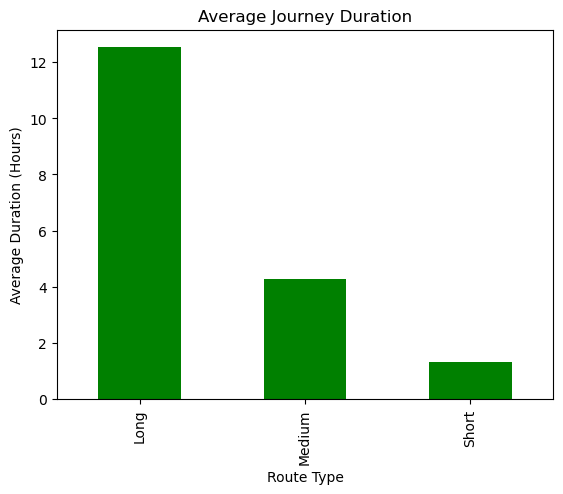

In [157]:
Avg_Duration_hours = Avg_Journey_Duration.dt.total_seconds()/3600
Avg_Duration_hours.plot(kind="bar",color="Green")
plt.title("Average Journey Duration")
plt.xlabel("Route Type")
plt.ylabel("Average Duration (Hours)")
plt.show()

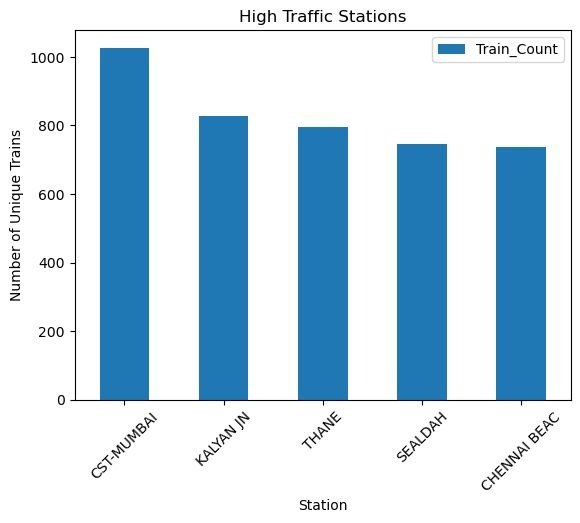

In [158]:
top_stations = Station_Wise_Train_Frequency .sort_values( "Train_Count", ascending=False).head(5)
top_stations.plot(x="Station_Name", y="Train_Count",kind="bar")
plt.title("High Traffic Stations")
plt.xlabel("Station")
plt.ylabel("Number of Unique Trains")
plt.xticks(rotation=45)
plt.show()

## Key Observations

The analysis displays a clear difference in Average journey duration across the three types of route categories. Short routes have an average journey time of approximately 1 hour 19 minutes, while medium routes take around 4 hours 16 minutes on average. Long routes have the highest average duration, at approximately 12 hours 32 minutes.

The station frequency analysis also highlights a few major stations with high train activity. CST-Mumbai has the highest number of unique trains, with 1,027 trains, followed by Kalyan Jn, Thane, Sealdah, and Chennai Beach. This suggests that these stations play an important role in connecting a large number of train routes.

Overall, the results show that journey duration varies substantially between route categories, while train activity is concentrated around a relatively small number of high-traffic stations. These findings provide a useful overview of the travel patterns and station connectivity represented in the dataset.